# cNLP4QoL Tutorial — ICHI 2026 Hands-On Session
### From Conversations to Quality-of-Life Insights in 20 Minutes

**Goal:** Run the full pipeline (raw → summaries → QoL tagging → four comparative metrics → visual dashboard)
on **5 conversations per dataset (10 total: MentalChat16K + Kaggle)**,
explore how **zero-shot vs. few-shot prompting** changes QoL tagging outcomes,
and discuss the central research question:

> *Is summarisation just compression, or does it act as a domain-bridging transformation?*

---
| Step | What you do | Time |
|------|-------------|------|
| T-0  | Setup: install deps, mount Drive, pick model | 2 min |
| T-1  | Load 5 × 2 conversations (MentalChat, Kaggle) + MultiWD few-shot bank | 1 min |
| T-2  | Generate PDSQI-9 summaries (3 prompt variants) | 4 min |
| T-3  | QoL tagging — zero-shot + few-shot × raw / patient / clinician representations | 5 min |
| T-4  | Comparative Metrics: PDSQI-9, coverage gap, fidelity, stylometrics | 4 min |
| T-5  | Visual dashboard | 2 min |
| T-6  | Save results + closing discussion | 3 min |

---
> **Two reference papers implemented in this tutorial**
> - **Croxford et al. 2025 (PDSQI-9, JAMIA)** — provider documentation quality instrument (Steps T-2, T-4a)
> - **Garg et al. 2025 (Stylometrics / Fidelity, Frontiers Psychiatry)** — stylometric analysis framework (Steps T-4c, T-4d)


## Step T-0: Setup

**What this step does:** Installs all required Python packages, mounts Google Drive, imports
standard libraries, and sets paths and model configuration used throughout the notebook.

**Why it matters:** All subsequent steps depend on the packages and variables defined here.
Run this cell first every time you open the notebook in a new Colab session.

**Model selection — discussion before running**

| Model | Params | Load time | Notes |
|-------|--------|-----------|-------|
| `Qwen2.5-3B-Instruct` | 3 B | ~3 min | Runs well in fp16 on T4 — **recommended default** |
| `meta-llama/Llama-3.1-8B-Instruct` | 8 B | ~8 min | Stronger reasoning; needs HF token |
| `gpt-5.4-nano` (OpenAI API) | — | <1 min | No GPU needed; requires API key; data leaves device |
| `google/flan-t5-base` | 250 M | <1 min | Very fast but weaker instruction-following |

> **Rule of thumb:** For *structured JSON output* (our use-case), a well-instructed 3 B model often
> matches an 8 B model while being 3× faster and using less VRAM.


In [ ]:
# T-0a  Install dependencies  (mirrors Step 0a of main notebook)
# Purpose: load all libraries needed for LLM inference, data handling, and visualisation.
!pip install -q transformers accelerate sentencepiece peft trl openai openpyxl tqdm datasets bitsandbytes

# T-0b  Mount Google Drive
# Purpose: give the notebook access to your dataset file and output directory.
from google.colab import drive
drive.mount("/content/drive")

import os, json, re, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
warnings.filterwarnings("ignore")

# T-0c  Paths
# IMPORTANT: VAL_MAIN_FILE must match the filename in your Drive exactly.
# The main research notebook uses 'Val_Datasets.xlsx' (with underscore).
DRIVE_ROOT    = "/content/drive/MyDrive/Colab Notebooks/Datasets"
VAL_MAIN_FILE = f"{DRIVE_ROOT}/Val_Datasets.xlsx"     # update if your filename differs
FEWSHOT_PATH  = f"{DRIVE_ROOT}/few_shot_dataset.txt"
OUT_DIR       = f"{DRIVE_ROOT}/tutorial_demo_v3_2"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_COLS = ["Spiritual", "Physical", "Intellectual", "Social", "Vocational", "Emotional"]

# T-0d  Dataset sheet names
# Pipeline datasets: MentalChat16K and Kaggle only.
# MultiWD is EXCLUDED from summary generation and QoL tagging —
# it serves exclusively as the few-shot example source (see T-1, T-3).
# Rationale: MultiWD is the most balanced / highest-quality dataset;
# its annotated examples give the few-shot tagger a strong prior,
# while MentalChat and Kaggle are the evaluation targets.
DATASET_SHEETS = {
    "mentalchat": "mc50",
    "kaggle":     "kaggle11",
}
FEWSHOT_DS     = "multiwd"   # source of few-shot examples; sheet = multiwd50
FEWSHOT_SHEET  = "multiwd50"
N_DEMO = 5          # conversations per evaluation dataset

# T-0e  Annotated gold prevalence rates
# ANNOTATED ground-truth positive rates per domain from the full 50-sample validation set.
# Source: Val_Outputs_Annotated_v2_Step6GoldEvalReport.xlsx, sheet 'Gold_Prevalence'
# Used in T-4b: coverage_gap = gold_rate - pred_rate  (NOT raw_rate - pred_rate).

GOLD_PREVALENCE = {
    "multiwd":    {"Spiritual":0.06,   "Physical":0.30,   "Intellectual":0.28,
                   "Social":0.54,   "Vocational":0.12,   "Emotional":0.66},
    "mentalchat": {"Spiritual":0.04,   "Physical":0.16,   "Intellectual":0.14,
                   "Social":0.70,   "Vocational":0.18,   "Emotional":0.88},
    "kaggle":     {"Spiritual":0.00,   "Physical":0.7273, "Intellectual":0.00,
                   "Social":0.9091, "Vocational":0.00,   "Emotional":1.00},
}

# T-0f  Model selector — change MODEL_CHOICE to switch backends
# Options: "qwen" | "llama" | "gpt" | "langextract"
MODEL_CHOICE       = "llama"                       # CHANGE ME
HF_QWEN            = "Qwen/Qwen2.5-3B-Instruct"
HF_LLAMA           = "meta-llama/Llama-3.1-8B-Instruct"
GPT_MODEL_PRIMARY  = "gpt-5.4-nano"
GPT_MODEL_FALLBACK = "gpt-4o-mini"
GPT_MODEL          = GPT_MODEL_PRIMARY            # may be updated to fallback in T-0g
MAX_NEW_TOK        = 420
TEMPERATURE        = 0.05

print(f"Model choice   : {MODEL_CHOICE}")
print(f"Datasets       : {list(DATASET_SHEETS.keys())} x {N_DEMO} convos each = {len(DATASET_SHEETS)*N_DEMO} total")
print(f"Output dir     : {OUT_DIR}")
print(f"GPU            : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU - slow!'}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.6 MB/s eta 0:00:00
Mounted at /content/drive
Model choice   : llama
Datasets       : ['mentalchat', 'kaggle'] x 5 convos each = 10 total
Output dir     : /content/drive/MyDrive/Colab Notebooks/Datasets/tutorial_demo_v3_2
GPU            : Tesla T4


We are calculating a binary prevalence estimate (what fraction of conversations contain domain X). the key quantity is the margin of error on the estimated rate. With manually annotated dataset with n=50 we can calculate the margin or error using a simple proportion:
Margin of error=1.96 X sqrt(p\(1-p)\/n)


| Domain       | Gold rate (MultiWD) | Margin of error at n=50 | Effective range |
| ------------ | ------------------- | ----------------------- | --------------- |
| Emotional    | 0.66                | ±0.131                  | 0.53 – 0.79     |
| Social       | 0.54                | ±0.138                  | 0.40 – 0.68     |
| Physical     | 0.30                | ±0.127                  | 0.17 – 0.43     |
| Intellectual | 0.28                | ±0.124                  | 0.16 – 0.40     |
| Vocational   | 0.12                | ±0.090                  | 0.03 – 0.21     |
| Spiritual    | 0.06                | ±0.066                  | 0.00 – 0.13     |

*The margins are wide! But this could plausibly be because of a small sample size and sampling absence.*

### T-0g: Load Selected Model

**What this step does:** Downloads and initialises the chosen model. For HuggingFace models
(Qwen / LLaMA) this loads weights into GPU memory. For GPT it creates an API client and
probes `gpt-5.4-nano`, falling back automatically to `gpt-4o-mini` if the primary is
unavailable. The `langextract` path imports ContextGem — see the optional section at the end.

**Why it matters:** All LLM calls in T-2, T-3, and T-4 share `call_llm()` which routes
through the object loaded here. No model load = no inference.


In [ ]:
# T-0g  Load the selected model  (mirrors Step 1 model-load of main notebook)
#
# LLaMA performance note (free Colab T4, 15 GB VRAM):
#   float16 (default) : ~16 GB VRAM, load ~8-12 min, may OOM on T4
#   4-bit NF4 (USE_4BIT=True): ~5-6 GB VRAM, load ~3-4 min, no OOM
#   Inference: 4-bit is ~2x faster per token, negligible quality loss
#              for classification tasks like QoL tagging.
#   Requires: bitsandbytes>=0.41.0  (installed in T-0a)
#
# Is the ~8-12 min load time expected for LLaMA?
#   YES. Llama-3.1-8B has 8 billion parameters (~16 GB in float16).
#   Downloading + loading 16 GB over Colab's shared network takes time.
#   Setting USE_4BIT=True below is the main fix: reduces load to ~3-4 min.
#   Alternative: use MODEL_CHOICE='qwen' (Qwen2.5-3B, ~6 GB, ~2 min load).

from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    pipeline as hf_pipeline, BitsAndBytesConfig
)
import time

gen = None        # HuggingFace text-generation pipeline (None if GPT/LangExtract)
tok = None
gpt_client = None
LANGEXTRACT_AVAILABLE = False

if MODEL_CHOICE == "qwen":
    print(f"Loading {HF_QWEN} ...")
    t0 = time.time()
    tok = AutoTokenizer.from_pretrained(HF_QWEN)
    mdl = AutoModelForCausalLM.from_pretrained(HF_QWEN, torch_dtype=torch.float16, device_map="auto")
    gen = hf_pipeline("text-generation", model=mdl, tokenizer=tok)
    print(f"Qwen ready.  ({time.time()-t0:.0f}s)")

elif MODEL_CHOICE == "llama":
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN") or os.environ.get("HF_TOKEN")
    if not hf_token:
        raise ValueError(
            "Set HF_TOKEN in Colab secrets (key icon in the left sidebar).\n"
            "Also accept the Meta license at:\n"
            "  https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct"
        )

    # ── 4-bit quantization toggle ─────────────────────────────────────────────
    # True  (recommended): NF4 quant via bitsandbytes — ~5-6 GB VRAM, ~3-4 min load
    # False : full float16 — ~16 GB VRAM, ~8-12 min load (may OOM on free T4)
    USE_4BIT = True

    print(f"Loading {HF_LLAMA} ...")
    print(f"  Mode: {'4-bit quantized (bitsandbytes NF4)' if USE_4BIT else 'float16 (full precision)'}")
    t0 = time.time()
    tok = AutoTokenizer.from_pretrained(HF_LLAMA, token=hf_token)

    if USE_4BIT:
        bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",           # NormalFloat4 — best quality/compression tradeoff
            bnb_4bit_use_double_quant=True,       # extra ~0.4 bits/param saved
            bnb_4bit_compute_dtype=torch.float16  # compute in fp16 for speed
        )
        mdl = AutoModelForCausalLM.from_pretrained(
            HF_LLAMA,
            quantization_config=bnb_cfg,
            device_map="auto",
            token=hf_token
        )
    else:
        mdl = AutoModelForCausalLM.from_pretrained(
            HF_LLAMA,
            torch_dtype=torch.float16,
            device_map="auto",
            token=hf_token
        )

    gen = hf_pipeline("text-generation", model=mdl, tokenizer=tok)
    elapsed = time.time() - t0
    print(f"LLaMA ready.  ({elapsed:.0f}s | {'4-bit NF4' if USE_4BIT else 'float16'})")
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        total     = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"  GPU VRAM used: {allocated:.1f} GB / {total:.1f} GB total")

elif MODEL_CHOICE == "gpt":
    from openai import OpenAI
    try:
        from google.colab import userdata
        key = userdata.get("openai_api_key")
    except Exception:
        key = os.environ.get("OPENAI_API_KEY")
    if not key:
        raise ValueError("Set openai_api_key in Colab secrets or OPENAI_API_KEY env var.")
    gpt_client = OpenAI(api_key=key)
    # Probe primary model; fall back automatically if unavailable
    try:
        gpt_client.chat.completions.create(
            model=GPT_MODEL_PRIMARY,
            messages=[{"role": "user", "content": "ping"}],
            max_completion_tokens=1)
        GPT_MODEL = GPT_MODEL_PRIMARY
        print(f"GPT backend ready: {GPT_MODEL}")
    except Exception as e:
        print(f"WARNING: {GPT_MODEL_PRIMARY} unavailable ({e}). Falling back to {GPT_MODEL_FALLBACK}.")
        GPT_MODEL = GPT_MODEL_FALLBACK
        print(f"GPT backend ready: {GPT_MODEL} (fallback)")

elif MODEL_CHOICE == "langextract":
    # ContextGem path -- see optional section at end of notebook.
    # API note: LLMPipeline / Concept / StringAspect were removed in contextgem v0.10+.
    # Current API (v0.17+): DocumentLLM, Document, BooleanConcept
    # Requires: openai_api_key in Colab secrets or OPENAI_API_KEY env var
    cg_llm = None
    try:
        from contextgem import DocumentLLM, Document, BooleanConcept
        LANGEXTRACT_AVAILABLE = True
        try:
            from google.colab import userdata
            _cg_key = userdata.get("openai_api_key")
        except Exception:
            _cg_key = os.environ.get("OPENAI_API_KEY")
        if not _cg_key:
            print("WARNING: No OpenAI key found. Set openai_api_key in Colab secrets.")
            LANGEXTRACT_AVAILABLE = False
        else:
            cg_llm = DocumentLLM(
                model=f"openai/{GPT_MODEL_PRIMARY}",
                api_key=_cg_key,
                temperature=0.0,
                max_tokens=512,
                num_retries_failed_request=3,
                max_retries_invalid_data=3,
            )
            print(f"ContextGem ready: openai/{GPT_MODEL_PRIMARY}")
    except ImportError:
        LANGEXTRACT_AVAILABLE = False
        cg_llm = None
        print("ContextGem not installed.")
        print("Install with:  !pip install contextgem  then restart the runtime.")


Loading meta-llama/Llama-3.1-8B-Instruct ...
  Mode: 4-bit quantized (bitsandbytes NF4)


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LLaMA ready.  (656s | 4-bit NF4)
  GPU VRAM used: 5.7 GB / 15.6 GB total


## Step T-1: Load 5 Conversations × 2 Evaluation Datasets + Few-Shot Bank

**What this step does:** Reads five randomly-sampled conversations from each of the two
evaluation datasets (MentalChat16K, Kaggle) from the shared Excel file.
It also loads a separate few-shot bank from the **MultiWD** training split —
MultiWD is *not* used for summary generation or QoL tagging itself;
it supplies labeled examples that guide the few-shot tagger in T-3.

**Why MultiWD for few-shot examples?**
MultiWD is the most balanced and richly annotated of the three datasets, with gold labels
across all six QoL domains. Drawing few-shot examples from it provides representative
positive examples for every domain, without contaminating the MentalChat/Kaggle evaluation set.
This mirrors the main research notebook (Step 2b), where `FEWSHOT_BANK` is built from
MultiWD training data and applied to external evaluation on Kaggle and MentalChat.

**Why only two evaluation datasets?**
MentalChat and Kaggle sit at different points on the social-media → clinical spectrum
(structured dialogues vs. Reddit posts), making them the most informative pair for
studying representation effects. MultiWD's role here is as a few-shot provider only.

| Dataset | Source style | Domain balance | Role in this tutorial |
|---------|-------------|----------------|----------------------|
| Kaggle | Reddit posts | Emotional-heavy (100%) | **Evaluation** — summary + tagging |
| MentalChat16K | Structured dialogues | Balanced | **Evaluation** — summary + tagging |
| MultiWD | Multi-domain dialogues | Most balanced (gold-labelled) | **Few-shot source only** |

**Output:** `all_demo_df` — 10 rows with columns `dataset`, `conv_id`, `text`.
`fs_df` — up to 30 MultiWD rows used to build the few-shot bank in T-3.

**Discussion questions**
1. What do you notice about text length differences between MentalChat and Kaggle?
2. Why would using MultiWD rows *as evaluation data* while also using them *as few-shot examples*
   be methodologically problematic?
3. Why is `random_state=42` important for reproducibility?


In [ ]:
# T-1  Load and standardise  (same logic as Step 0d in main notebook)
# standardize_text_column handles different column naming conventions:
#   - single-column layouts (text, conversation, dialogue, ...)
#   - two-column layouts (patient/therapist, user/assistant, ...)
#   - fallback: concatenate all object columns

SINGLE_COLS = ["text","conversation","dialogue","dialog","utterance","content","transcript"]
PAIR_COLS   = [("patient","therapist"),("user","assistant"),("speaker1","speaker2"),
               ("input","response"),("question","answer")]

def standardize_text_column(df, name):
    df = df.copy()
    for c in SINGLE_COLS:
        if c in df.columns:
            df["text"] = df[c].fillna("").astype(str)
            break
    if "text" not in df.columns:
        for c1, c2 in PAIR_COLS:
            if c1 in df.columns and c2 in df.columns:
                df["text"] = ("Patient: " + df[c1].fillna("").astype(str) +
                              "\nTherapist: " + df[c2].fillna("").astype(str))
                break
    if "text" not in df.columns:
        obj_cols = [c for c in df.columns if df[c].dtype == object]
        df["text"] = df[obj_cols].fillna("").astype(str).agg(" ".join, axis=1)
    df["text"] = df["text"].fillna("").astype(str).str.strip()
    return df[df["text"] != ""].reset_index(drop=True)

# ── Evaluation datasets: MentalChat + Kaggle ─────────────────────────────────
# MultiWD is intentionally excluded from this loop — see T-0d and T-3 for rationale.
demo_frames = []
for ds_name, sheet in DATASET_SHEETS.items():
    try:
        df = pd.read_excel(VAL_MAIN_FILE, sheet_name=sheet, engine="openpyxl")
        df = standardize_text_column(df, ds_name)
        sample = df.sample(n=min(N_DEMO, len(df)), random_state=42).reset_index(drop=True)
        sample["dataset"] = ds_name
        sample["conv_id"] = [f"{ds_name}_{i}" for i in range(len(sample))]
        demo_frames.append(sample[["dataset", "conv_id", "text"]])
        print(f"  {ds_name}: loaded {len(sample)} conversations (sheet '{sheet}')")
    except Exception as e:
        print(f"  {ds_name}: FAILED — {e}")

all_demo_df = pd.concat(demo_frames, ignore_index=True)
print(f"\nall_demo_df: {all_demo_df.shape}  (10 rows expected: 5 MentalChat16K + 5 Kaggle11)")

# ── Few-shot source: MultiWD (separate, not added to all_demo_df) ─────────────
# MultiWD rows are loaded here ONLY to build the few-shot bank in T-3b.
# They are NOT summarised and NOT evaluated — keeping evaluation and few-shot
# source sets strictly separate (mirrors main notebook Step 2b).
try:
    fs_raw = pd.read_excel(VAL_MAIN_FILE, sheet_name=FEWSHOT_SHEET, engine="openpyxl")
    fs_raw = standardize_text_column(fs_raw, FEWSHOT_DS)
    # Keep up to 30 rows for bank construction; exclude any overlap with eval sample
    fs_df  = fs_raw.sample(n=min(30, len(fs_raw)), random_state=99).reset_index(drop=True)
    fs_df["dataset"]  = FEWSHOT_DS
    fs_df["conv_id"]  = [f"{FEWSHOT_DS}_fs_{i}" for i in range(len(fs_df))]
    print(f"\n  few-shot bank source: MultiWD ({len(fs_df)} rows loaded from '{FEWSHOT_SHEET}')")
    print("  [These rows will be used in T-3b to build FEWSHOT_BANK — NOT evaluated here]")
except Exception as e:
    fs_df = pd.DataFrame()
    print(f"  WARNING: Could not load MultiWD few-shot source: {e}")
    print("  T-3b will fall back to hand-crafted examples.")

print(f"\nDatasets in pipeline: {all_demo_df['dataset'].unique().tolist()}")
print(f"Few-shot source dataset: {FEWSHOT_DS} ({len(fs_df)} rows)")


  mentalchat: loaded 5 conversations (sheet 'mc50')
  kaggle: loaded 5 conversations (sheet 'kaggle11')

all_demo_df: (10, 3)  (10 rows expected: 5 MentalChat16K + 5 Kaggle11)

  few-shot bank source: MultiWD (30 rows loaded from 'multiwd50')
  [These rows will be used in T-3b to build FEWSHOT_BANK — NOT evaluated here]

Datasets in pipeline: ['mentalchat', 'kaggle']
Few-shot source dataset: multiwd (30 rows)


## Step T-2: PDSQI-9 Summary Generation — Prompt Variations

**What this step does:** Generates two perspectives (patient-voice and clinician-voice)
for each of the 10 evaluation conversations (MentalChat + Kaggle).
MultiWD is excluded from this step — it is used only as the few-shot source for T-3. The full Prompt B body is defined in a **visible,
executable cell** so participants can inspect every PDSQI-9 rule before summaries run.

**Why PDSQI-9?** The instrument (Croxford et al. 2025, JAMIA) defines 9 attributes a
high-quality clinical summary must have. By encoding these rules into the prompt, we test
whether LLMs can meet clinical documentation quality standards without human editing.

**Three prompt variants:**

| Variant | Key design | What it tests |
|---------|-----------|---------------|
| Prompt A | Minimal — no rules, no domain tags | Baseline |
| Prompt B | Full 9 PDSQI-9 rules + citations + domain tags | Main-notebook production prompt |
| Prompt C | PDSQI-9 + chain-of-thought prefix | Does explicit reasoning improve compliance? |

Prompt B is run for all 10 evaluation conversations. Prompts A and C are run on MentalChat conv 0
only, for the side-by-side comparison in dashboard Panel F.

**Output:** `summary_df` — 10 rows with `dataset`, `conv_id`, `raw_text`,
`patient_summary`, `clinician_summary`.

**Discussion questions**
1. In Prompt A vs B, which summary would a patient find more readable?
2. Does chain-of-thought (Prompt C) improve domain coverage or just add length?
3. Which variant would you choose if the goal is downstream QoL tagging accuracy?


In [ ]:
# T-2a  Shared call_llm helper  (same interface as main notebook Step 1)
# Routes to HuggingFace pipeline or OpenAI API based on MODEL_CHOICE.
# Retries GPT calls up to 3 times with 2-second backoff on failure.

VLLM_SYS_SUM = "You are a PDSQI-9-compliant clinical documentation assistant."

def call_llm(prompt, system_msg=VLLM_SYS_SUM, max_tokens=MAX_NEW_TOK, temp=TEMPERATURE):
    if MODEL_CHOICE in ("qwen","llama") and gen is not None:
        messages = [{"role":"system","content":system_msg},
                    {"role":"user","content":prompt}]
        formatted = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        out = gen(formatted, max_new_tokens=max_tokens, do_sample=False,
                  return_full_text=False, pad_token_id=tok.eos_token_id)
        return out[0]["generated_text"].strip()
    elif MODEL_CHOICE == "gpt" and gpt_client:
        for attempt in range(3):
            try:
                r = gpt_client.chat.completions.create(
                    model=GPT_MODEL,
                    messages=[{"role":"system","content":system_msg},
                               {"role":"user","content":prompt}],
                    temperature=0.0, max_completion_tokens=max_tokens)
                return r.choices[0].message.content.strip()
            except Exception as e:
                print(f"  GPT attempt {attempt+1}/3 failed: {e}")
                time.sleep(2)
        return "ERROR: GPT call failed after 3 attempts"
    else:
        return "ERROR: no model loaded"

print("call_llm helper defined.")


call_llm helper defined.


In [ ]:
# T-2b  Few-shot examples for patient and clinician perspectives
# Verbatim from main notebook. These teach the model expected output format.

DIALOGUE_FEWSHOT_PATIENT = '--- EXAMPLE (FIRST-PERSON, PATIENT VOICE) ---\nTranscript: Patient: I have not been sleeping well; I keep worrying about losing my job.\nTherapist: Are you still connected with your family?\nPatient: Not really. I feel like a burden to them.\nIdentified domains: Physical, Emotional, Social, Vocational\nPatient-perspective summary:\n[Physical] I have not been sleeping well lately, and the restlessness is wearing me down. (Source: patient turn 1)\n[Vocational] I keep worrying that I might lose my job, and that fear sits with me all day. (Source: patient turn 1)\n[Emotional] I feel anxious and weighed down by a constant sense that I am a burden to the people I love. (Source: patient turns 1, 3)\n[Social] I do not feel close to my family right now; I keep pulling back because I think I am draining them. (Source: patient turn 3)\n--- END EXAMPLE ---'

DIALOGUE_FEWSHOT_CLINICIAN = '--- EXAMPLE (THIRD-PERSON, CLINICIAN VOICE) ---\nTranscript: Patient: I have not been sleeping well; I keep worrying about losing my job.\nTherapist: Are you still connected with your family?\nPatient: Not really. I feel like a burden to them.\nIdentified domains: Physical, Emotional, Social, Vocational\nClinician-perspective summary:\n[Physical] Patient reports significant sleep disturbance affecting daily functioning. (Source: turn 1)\n[Vocational] Patient endorses persistent occupational worry regarding job security. (Source: turn 1)\n[Emotional] Patient presents with anxiety and self-directed shame, framing self as a burden. (Source: turns 1, 3)\n[Social] Patient indicates diminished family connectedness and perceived relational strain. (Source: turn 3)\n--- END EXAMPLE ---'

print("Few-shot example blocks defined.")


Few-shot example blocks defined.


In [ ]:
# T-2c  Three prompt variants — FULL DEFINITIONS (visible before first use)
# PDSQI-9 RULES (Croxford et al. 2025, JAMIA):
#   Rule 1  ACCURATE       - every claim grounded in the transcript
#   Rule 2  CITED          - (Source: turn N) citation after EVERY sentence
#   Rule 3  THOROUGH       - all identified QoL domains covered
#   Rule 4  USEFUL         - patient: first-person plain language; clinician: third-person clinical
#   Rule 5  ORGANIZED      - [Domain] tag at the start of each sentence
#   Rule 6  COMPREHENSIBLE - patient: no jargon; clinician: correct terminology
#   Rule 7  SUCCINCT       - 4-7 sentences total
#   Rule 8  SYNTHESIZED    - merge across turns; do not copy verbatim
#   Rule 9  NON-STIGMATIZING - person-first language; no diagnostic labels

def prompt_A_patient(text):
    """Minimal patient prompt — no PDSQI-9 constraints."""
    return ("You are the patient. Write a short personal reflection (3-5 sentences) about what "
            "was on your mind during today's therapy session. Use first person. Plain language.\n"
            f"Transcript:\n{text}\nreflection:")

def prompt_A_clinician(text):
    """Minimal clinician prompt — no PDSQI-9 constraints."""
    return ("You are a clinical scribe. Write a brief (3-5 sentence) clinical note about the patient "
            "in this transcript. Third person, standard clinical language.\n"
            f"Transcript:\n{text}\nnote:")

def prompt_B_patient(text, domains="Spiritual,Physical,Intellectual,Social,Vocational,Emotional"):
    """Standard PDSQI-9 patient prompt — mirrors main notebook build_patient_prompt."""
    return (
        "ROLE: You ARE the patient writing a diary-style reflection.\n"
        "VOICE: First person only (I/me/my). No clinical verbs (reports, exhibits, endorses).\n"
        "PDSQI-9 RULES:\n"
        "1. ACCURATE       - ground every claim in the transcript.\n"
        "2. CITED          - add (Source: patient turn <N>) after EVERY sentence.\n"
        "3. THOROUGH       - cover EVERY domain listed below.\n"
        "4. USEFUL         - empathetic, plain language a patient would use.\n"
        "5. ORGANIZED      - start each sentence with a [Domain] tag.\n"
        "6. COMPREHENSIBLE - your own voice; no medical jargon.\n"
        "7. SUCCINCT       - 4-7 sentences total.\n"
        "8. SYNTHESIZED    - merge across turns; do not copy verbatim.\n"
        "9. NON-STIGMATIZING - no diagnostic labels; person-first language.\n"
        f"IDENTIFIED QoL DOMAINS (must all be covered): {domains}\n"
        f"{DIALOGUE_FEWSHOT_PATIENT}\n"
        f"Transcript:\n{text}\n"
        "Patient-perspective summary in MY own voice, first person:"
    )

def prompt_B_clinician(text, domains="Spiritual,Physical,Intellectual,Social,Vocational,Emotional"):
    """Standard PDSQI-9 clinician prompt — mirrors main notebook build_clinician_prompt."""
    return (
        "You are an expert clinical scribe preparing a QoL-focused note.\n"
        "PDSQI-9 RULES:\n"
        "1. ACCURATE       - every observation supported by transcript evidence.\n"
        "2. CITED          - add (Source: turn <N>) after EVERY sentence.\n"
        "3. THOROUGH       - document ALL identified domains below.\n"
        "4. USEFUL         - third-person clinical language (Patient reports...).\n"
        "5. ORGANIZED      - start each sentence with a [Domain] tag.\n"
        "6. COMPREHENSIBLE - standard clinical terminology; avoid colloquialisms.\n"
        "7. SUCCINCT       - 4-7 sentences maximum.\n"
        "8. SYNTHESIZED    - integrate multiple turns; do not copy verbatim.\n"
        "9. NON-STIGMATIZING - person-first, recovery-oriented language.\n"
        f"IDENTIFIED QoL DOMAINS (must all be covered): {domains}\n"
        f"{DIALOGUE_FEWSHOT_CLINICIAN}\n"
        f"Transcript:\n{text}\n"
        "Clinician-perspective summary:"
    )

def prompt_C_patient(text, domains="Spiritual,Physical,Intellectual,Social,Vocational,Emotional"):
    """Chain-of-thought PDSQI-9 patient prompt."""
    return (
        "Think step-by-step before writing the summary:\n"
        "Step 1: list each patient turn and the QoL domain it touches.\n"
        "Step 2: check you have evidence for every required domain.\n"
        "Step 3: write the final summary in the patient's first-person voice.\n\n"
        + prompt_B_patient(text, domains)
        + "\n\nWith Step 1-2 reasoning first, then output after FINAL SUMMARY:"
    )

def prompt_C_clinician(text, domains="Spiritual,Physical,Intellectual,Social,Vocational,Emotional"):
    """Chain-of-thought PDSQI-9 clinician prompt."""
    return (
        "Think step-by-step:\n"
        "Step 1: identify each turn and its QoL evidence.\n"
        "Step 2: verify all required domains are addressed.\n"
        "Step 3: write the final clinical note.\n\n"
        + prompt_B_clinician(text, domains)
        + "\n\nWith Step 1-2 reasoning first, then output after FINAL SUMMARY:"
    )

print("Prompt variants A, B, C defined for both patient and clinician perspectives.")
print("Prompt B encodes all 9 PDSQI-9 rules from Croxford et al. 2025 (JAMIA).")


Prompt variants A, B, C defined for both patient and clinician perspectives.
Prompt B encodes all 9 PDSQI-9 rules from Croxford et al. 2025 (JAMIA).


### T-2d: Run Summaries for All 15 Conversations

**What this step does:** Calls `call_llm()` with Prompt B for both perspectives across
all 15 conversations. Prompt A and Prompt C are additionally run on MultiWD conv 0 for
the side-by-side dashboard comparison.

**Output per row:** `conv_id`, `dataset`, `raw_text`, `patient_summary`, `clinician_summary`.

**Timing note:** This step runs 30+ LLM calls. On a free Colab T4 with Qwen2.5-3B,
expect 8-12 minutes. For a live demo, pre-run and cache results before the session.


In [ ]:
# T-2d  Generate Prompt B summaries for all 15 conversations
from tqdm import tqdm

DEFAULT_DOMAINS = "Spiritual,Physical,Intellectual,Social,Vocational,Emotional"

results = []
# Generates summaries for MentalChat + Kaggle only (MultiWD excluded from evaluation).
for _, row in tqdm(all_demo_df.iterrows(), total=len(all_demo_df), desc="Generating summaries"):
    text   = row["text"]
    pat_B  = call_llm(prompt_B_patient(text, DEFAULT_DOMAINS))
    clin_B = call_llm(prompt_B_clinician(text, DEFAULT_DOMAINS))
    results.append({
        "dataset":          row["dataset"],
        "conv_id":          row["conv_id"],
        "raw_text":         text,
        "patient_summary":  pat_B,
        "clinician_summary": clin_B,
    })
    print(f"\n[{row['dataset']}] {row['conv_id']}")
    print(f"  Patient  B: {pat_B[:120]}")
    print(f"  Clinician B: {clin_B[:120]}")

summary_df = pd.DataFrame(results)
print(f"\nsummary_df: {summary_df.shape}  (10 rows expected: 5 MentalChat + 5 Kaggle)")

# Side-by-side: Prompt A and C on MentalChat conv 0 for dashboard Panel F
# (MultiWD is not in all_demo_df — using MentalChat as the reference conversation)
conv0_row = all_demo_df[all_demo_df["dataset"] == "mentalchat"].iloc[0]
conv0     = conv0_row["text"]
pat_A     = call_llm(prompt_A_patient(conv0))
clin_A    = call_llm(prompt_A_clinician(conv0))
pat_C_raw = call_llm(prompt_C_patient(conv0, DEFAULT_DOMAINS))
cot_match = re.search(r"FINAL SUMMARY[:\s]*(.*)", pat_C_raw, re.DOTALL)
pat_C     = cot_match.group(1).strip() if cot_match else pat_C_raw

print("\n== SIDE-BY-SIDE: MultiWD Conv 0 | Patient Perspective ==")
print(f"\nPrompt A (Minimal):\n{pat_A}\n")
mw0_ref = summary_df[(summary_df["dataset"]=="mentalchat")].iloc[0]["patient_summary"]
print(f"Prompt B (PDSQI-9 Standard):\n{mw0_ref}\n")
print(f"Prompt C (PDSQI-9 Chain-of-Thought):\n{pat_C}")


Generating summaries:   0%|          | 0/10 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Generating summaries:


[mentalchat] mentalchat_0
  Patient  B: [Physical] I've been feeling overwhelmed by the constant need to address others' needs, which has taken a toll on my own
  Clinician B: [Physical] Patient reports improved ability to prioritize personal needs and concerns, potentially indicating enhanced s


Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Generating summaries:  20%|██        | 2/10 [01:29<05:53, 44.14s/it]Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[mentalchat] mentalchat_1
  Patient  B: [Physical] I've been feeling drained and disconnected from my work, which is affecting my overall well-being. (Source: p
  Clinician B: [Physical] Patient reports no specific physical symptoms or concerns at this time. (Source: turn 1)

[Intellectual] Pati


Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Generating summaries:  30%|███       | 3/10 [02:21<05:33, 47.58s/it]Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


[kaggle] kaggle_3
  Patient  B: [Physical] I've been feeling drained and exhausted from the constant stress and anxiety that comes with dealing with my 
  Clinician B: [Physical] Patient reports no specific physical complaints or concerns. (Source: no mention of physical issues)

[Vocati


Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Generating summaries: 100%|██████████| 10/10 [09:24<00:00, 56.44s/it]
Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[kaggle] kaggle_4
  Patient  B: [Physical] I've been feeling a bit worn out lately, but I'm not sure if it's due to lack of sleep or something else. (So
  Clinician B: [Physical] Patient reports no specific physical symptoms or concerns at this time. (Source: turns 1-5)

[Intellectual] P

summary_df: (10, 5)  (10 rows expected: 5 MentalChat + 5 Kaggle)


Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



== SIDE-BY-SIDE: MultiWD Conv 0 | Patient Perspective ==

Prompt A (Minimal):
Today's session felt really empowering. I finally felt like I could breathe and focus on my own stuff without all the other stuff from the past weighing me down. Talking about my relationship with my partner was really helpful - it's been bothering me for a while, and it feels good to have a plan to work on it. I'm hoping this new approach will help me be more confident in setting boundaries and communicating my needs.

Prompt B (PDSQI-9 Standard):
[Physical] I've been feeling overwhelmed by the constant need to address others' needs, which has taken a toll on my own well-being, leaving me drained and exhausted. (Source: patient turn 1)
[Intellectual] I've had to think critically about my own needs and boundaries, which has helped me understand what I want and need in a relationship. (Source: patient turn 2)
[Emotional] I feel more in control and empowered after this new intervention, which has given me the 

## Step T-3: QoL Tagging — Zero-Shot and Few-Shot

**What this step does:** Tags each of the 10 evaluation conversations in three representations
(raw text, patient summary, clinician summary) using **two tagging modes**:

| Mode | Description | Prompt includes |
|------|-------------|-----------------|
| **Zero-shot (ZS)** | No examples — model relies on domain descriptions alone | Task instruction only |
| **Few-shot (FS)** | 1 labeled example per QoL domain drawn from MultiWD training data | Task instruction + 6 examples |

**Why two modes?** Zero-shot tagging tests the model's intrinsic domain knowledge.
Few-shot tagging tests whether seeing one labeled MultiWD example per domain improves
detection — especially for rare domains (Spiritual, Vocational, Intellectual) that the
model may under-predict in zero-shot mode.

**Why MultiWD as the few-shot source?**
The few-shot examples come exclusively from MultiWD training data — the same source used in
the main research notebook (Step 2b, `FEWSHOT_BANK`). MultiWD is the most balanced dataset,
with gold labels across all six QoL domains, making it an ideal provider of representative
positive examples. Crucially, MultiWD rows are **never** used as evaluation data in this
tutorial — keeping the few-shot source and the evaluation set strictly separate.

**Per-row vs. aggregate:**
Each row in `tag_df_zs` / `tag_df_fs` = one **(conv_id, representation)** binary prediction.
The mean printed at the end = **aggregate positive rate** across 5 conversations per dataset.

**Output:**
- `tag_df_zs` — 30 rows (10 convos × 3 reps) — zero-shot predictions
- `tag_df_fs` — 30 rows (10 convos × 3 reps) — few-shot predictions
- `FEWSHOT_BANK` — dict of labeled MultiWD examples used in few-shot mode
- `tag_df` — combined 60-row DataFrame (both modes) used in T-4 and T-5

**Discussion questions**
1. Which domains improve the most between zero-shot and few-shot tagging?
2. Does few-shot tagging help more for raw text or for summaries? Why might that be?
3. Do few-shot examples from MultiWD transfer well to Kaggle (Reddit-style) text?
   What does this tell us about domain adaptation?


In [ ]:
##T-3a  QoL tagging helpers  (exact copy from main notebook Step 2)

QOL_TAGGING_SYS = (
    "You are a Quality of Life domain classifier for mental-health text.\n"
    "Return ONLY valid JSON. Do not explain your answer.\n"
    "Assign 1 only when the text contains direct evidence for the domain."
)

def build_qol_tagging_prompt(text, fewshot_block=None):
    fs = f"Few-shot examples:\n{fewshot_block}\n\n" if fewshot_block else ""
    return (
        f"{fs}Task: Read the input text and determine whether each QoL domain is present.\n"
        "Domains: Spiritual | Physical | Intellectual | Social | Vocational | Emotional\n"
        "Rules:\n"
        "- Return 1 if the domain is directly supported by the text.\n"
        "- Return 0 otherwise.\n"
        "- Conversation-level classification (not sentence-level).\n"
        "- Do not infer beyond what is explicitly stated.\n"
        '- Return ONLY valid JSON: {"Spiritual":0,"Physical":0,"Intellectual":0,'
        '"Social":0,"Vocational":0,"Emotional":0}\n'
        f"Text: {text}"
    )

def parse_label_json(raw_text):
    default = {k: 0 for k in LABEL_COLS}
    try:
        m = re.search(r"\{.*?\}", raw_text, re.DOTALL)
        if not m:
            return default, True, raw_text
        obj = json.loads(m.group())
        out = {k: (1 if str(obj.get(k,0)).strip().lower() in ("1","1.0","true") or obj.get(k)==1 else 0)
               for k in LABEL_COLS}
        return out, False, raw_text
    except Exception:
        return default, True, raw_text

def call_open_qol_classifier(text, fewshot_block=None):
    prompt = build_qol_tagging_prompt(text, fewshot_block)
    messages = [{"role":"system","content":QOL_TAGGING_SYS},
                {"role":"user","content":prompt}]
    formatted = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    out = gen(formatted, max_new_tokens=200, do_sample=False,
              return_full_text=False, pad_token_id=tok.eos_token_id)
    return parse_label_json(out[0]["generated_text"].strip())

def call_gpt_qol_classifier(text, fewshot_block=None):
    prompt = build_qol_tagging_prompt(text, fewshot_block)
    for attempt in range(3):
        try:
            r = gpt_client.chat.completions.create(
                model=GPT_MODEL,
                messages=[{"role":"system","content":QOL_TAGGING_SYS},
                           {"role":"user","content":prompt}],
                temperature=0.0, max_completion_tokens=200)
            return parse_label_json(r.choices[0].message.content.strip())
        except Exception as e:
            time.sleep(2)
    return parse_label_json("ERROR: GPT call failed")

print("QoL tagging helpers ready.")


QoL tagging helpers ready.


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# T-3b  Few-shot bank -- loads from few_shot_dataset.txt (FEWSHOT_PATH)
#
# Source: FEWSHOT_PATH = f"{DRIVE_ROOT}/few_shot_dataset.txt"
#         (your Google Drive, same folder as Val_Datasets.xlsx)
#
# The file was created from MultiWD training data -- the same source used in
# the main research notebook (Step 2b, FEWSHOT_BANK). MultiWD is the most
# balanced dataset and provides gold labels across all six QoL domains.
#
# File format: 'Example N:' blocks, each containing:
#   [PATIENT]: "<conversation text>"
#   Response:
#   {"qol_domains": ["Physical Well-Being", ...], "confidence": [...], ...}
#
# Domain name mapping (file -> notebook LABEL_COLS):
#   'Physical Well-Being'   -> 'Physical'
#   'Emotional Well-Being'  -> 'Emotional'
#   'Social Functioning'    -> 'Social'
#   'Intellectual State'    -> 'Intellectual'
#   'Vocational'            -> 'Vocational'  (unchanged)
#   'Spiritual Perspective' -> 'Spiritual'
#
# Selection: for each domain, the first file entry where that domain is
# positive is used. If the file is missing or a domain has no positive entry,
# the hand-crafted FEWSHOT_FALLBACK is used for that domain.
# ────────────────────────────────────────────────────────────────────────────

# Domain name normalisation: maps long-form names from file to LABEL_COLS short names
DOMAIN_NAME_MAP = {
    "physical well-being":   "Physical",
    "emotional well-being":  "Emotional",
    "social functioning":    "Social",
    "intellectual state":    "Intellectual",
    "vocational":            "Vocational",
    "spiritual perspective": "Spiritual",
    # Also accept the short names directly (in case file changes)
    "physical":              "Physical",
    "emotional":             "Emotional",
    "social":                "Social",
    "intellectual":          "Intellectual",
    "spiritual":             "Spiritual",
}

def normalise_domain(name):
    return DOMAIN_NAME_MAP.get(name.strip().lower())


# Hand-crafted fallback examples (used only when FEWSHOT_PATH is missing or
# has no positive entry for a given domain).
FEWSHOT_FALLBACK = {
    "Spiritual": (
        "I have been thinking a lot about what gives my life meaning. "
        "Church used to feel like an anchor, but lately I feel disconnected from that too.",
        {"Spiritual":1,"Physical":0,"Intellectual":0,"Social":1,"Vocational":0,"Emotional":1}
    ),
    "Physical": (
        "My back pain has been getting worse. I can barely get through a shift at work "
        "without needing to sit down every hour.",
        {"Spiritual":0,"Physical":1,"Intellectual":0,"Social":0,"Vocational":1,"Emotional":0}
    ),
    "Intellectual": (
        "I have been having trouble concentrating at school. My mind just wanders "
        "and I cannot retain information the way I used to.",
        {"Spiritual":0,"Physical":0,"Intellectual":1,"Social":0,"Vocational":0,"Emotional":1}
    ),
    "Social": (
        "My friends stopped inviting me out months ago. I know I pushed them away "
        "but I do not know how to reconnect.",
        {"Spiritual":0,"Physical":0,"Intellectual":0,"Social":1,"Vocational":0,"Emotional":1}
    ),
    "Vocational": (
        "I got passed over for promotion again. I put in extra hours all quarter "
        "and my manager did not even mention my name.",
        {"Spiritual":0,"Physical":0,"Intellectual":0,"Social":0,"Vocational":1,"Emotional":1}
    ),
    "Emotional": (
        "Most mornings I do not want to get out of bed. The anxiety hits before I even open my eyes.",
        {"Spiritual":0,"Physical":0,"Intellectual":0,"Social":0,"Vocational":0,"Emotional":1}
    ),
}


def load_fewshot_txt(path):
    """
    Parse few_shot_dataset.txt and return a list of dicts:
      {"text": str, "labels": {domain: 0|1, ...}}

    Format expected:
      Example N:
      [PATIENT]: "<text>"
      Response:
      {"qol_domains": ["Physical Well-Being", ...], ...}

    Domain names are normalised via DOMAIN_NAME_MAP.
    Returns [] if file is missing or unreadable.
    """
    if not os.path.exists(path):
        print(f"  [T-3b] WARNING: {path} not found -- using hand-crafted fallback examples.")
        return []

    with open(path, encoding="utf-8") as fh:
        raw = fh.read()

    blocks = re.split(r'\nExample \d+:\n', '\n' + raw)
    blocks = [b.strip() for b in blocks if b.strip()]

    records = []
    for block in blocks:
        # Extract patient text (may or may not be quoted)
        pt = re.search(r'\[PATIENT\]:\s*"?(.*?)"?\nResponse:', block, re.DOTALL)
        jt = re.search(r'Response:\s*(\{.*?\})\s*$', block, re.DOTALL)
        if not pt or not jt:
            continue
        text = pt.group(1).strip().strip('"')
        try:
            resp = json.loads(jt.group(1))
        except json.JSONDecodeError:
            continue
        raw_domains = resp.get("qol_domains", [])
        labels = {d: 0 for d in LABEL_COLS}
        for rd in raw_domains:
            short = normalise_domain(rd)
            if short and short in labels:
                labels[short] = 1
        if text:
            records.append({"text": text, "labels": labels})

    print(f"  [T-3b] Loaded {len(records)} examples from {os.path.basename(path)}")
    return records


def format_fewshot_example(text, labels):
    label_json = json.dumps({k: labels.get(k, 0) for k in LABEL_COLS})
    return f"Text: {text}\nLabels: {label_json}"


# ── Load and build FEWSHOT_BANK ───────────────────────────────────────────────
# few_shot_dataset.txt is sourced from MultiWD training data.
# It contains 119 labeled examples with QoL domain annotations.
# See T-1 and T-3 markdown cells for full rationale on MultiWD as few-shot source.
print(f"Loading few-shot examples from: {FEWSHOT_PATH}")
print("  (Source: MultiWD training data -- see T-1 and T-3 for rationale)\n")

fewshot_records = load_fewshot_txt(FEWSHOT_PATH)

FEWSHOT_BANK = {}
for domain in LABEL_COLS:
    found = False
    for rec in fewshot_records:
        if rec["labels"].get(domain, 0) == 1:
            FEWSHOT_BANK[domain] = {"text": rec["text"], "labels": rec["labels"]}
            found = True
            break
    if not found:
        text_fb, labels_fb = FEWSHOT_FALLBACK[domain]
        FEWSHOT_BANK[domain] = {"text": text_fb, "labels": labels_fb}

# Assemble the few-shot block string (all 6 examples concatenated)
FEWSHOT_BLOCK = "\n".join(
    f"[Example for {domain}]\n" + format_fewshot_example(
        FEWSHOT_BANK[domain]["text"], FEWSHOT_BANK[domain]["labels"]
    )
    for domain in LABEL_COLS
)

print("Few-shot bank built (MultiWD training data via few_shot_dataset.txt):")
src_counts = {"file": 0, "fallback": 0}
for domain, ex in FEWSHOT_BANK.items():
    is_from_file = any(r["text"] == ex["text"] for r in fewshot_records)
    src = "few_shot_dataset.txt" if is_from_file else "hand-crafted fallback"
    src_counts["file" if is_from_file else "fallback"] += 1
    print(f"  {domain:15s}: {str(ex['text'])[:75]}...  [{src}]")

print(f"\nSource summary: {src_counts['file']} from file, {src_counts['fallback']} from fallback")
print(f"Few-shot block length: {len(FEWSHOT_BLOCK)} chars, {len(FEWSHOT_BLOCK.splitlines())} lines")

# T-3c  Tag all three representations — ZERO-SHOT mode
#
# Zero-shot: no examples provided; model relies on the task description alone.
# Baseline for comparison with few-shot.
# ─────────────────────────────────────────────────────────────────────────────
CALLER = call_gpt_qol_classifier if (MODEL_CHOICE == "gpt" and gpt_client) else call_open_qol_classifier

print("\n=== T-3c: Zero-Shot Tagging ===")
tag_records_zs = []
for _, row in tqdm(summary_df.iterrows(), total=len(summary_df), desc="Tagging (zero-shot)"):
    for rep, txt in [("raw",       row["raw_text"]),
                     ("patient",   row["patient_summary"]),
                     ("clinician", row["clinician_summary"])]:
        labels, parse_err, _ = CALLER(txt, fewshot_block=None)   # zero-shot: no examples
        rec = {"dataset": row["dataset"], "conv_id": row["conv_id"],
               "representation": rep, "tagging_mode": "zero_shot"}
        rec.update({f"{k}_pred": v for k, v in labels.items()})
        rec["parse_error"] = int(parse_err)
        tag_records_zs.append(rec)

tag_df_zs = pd.DataFrame(tag_records_zs)
print(f"tag_df_zs shape: {tag_df_zs.shape}  (expected 30: 10 convos × 3 reps)")
print(f"Parse errors (ZS): {tag_df_zs['parse_error'].sum()} / {len(tag_df_zs)}")

print("\nZero-shot mean predicted positive rate (all datasets combined):")
print(tag_df_zs.groupby("representation")[[f"{k}_pred" for k in LABEL_COLS]]
      .mean().round(2).rename(columns=lambda c: c.replace("_pred","")))

# ─────────────────────────────────────────────────────────────────────────────
# T-3d  Tag all three representations — FEW-SHOT mode
#
# Few-shot: FEWSHOT_BLOCK (6 MultiWD-derived examples, one per domain) is
# prepended to each tagging prompt. This mirrors main notebook Step 2b
# (call_open_qol_classifier with few_shot_block=make_fewshot_block(...)).
#
# The same CALLER function is used — fewshot_block is passed as an argument,
# so this is a direct apples-to-apples comparison with T-3c.
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== T-3d: Few-Shot Tagging (MultiWD examples) ===")
tag_records_fs = []
for _, row in tqdm(summary_df.iterrows(), total=len(summary_df), desc="Tagging (few-shot)"):
    for rep, txt in [("raw",       row["raw_text"]),
                     ("patient",   row["patient_summary"]),
                     ("clinician", row["clinician_summary"])]:
        labels, parse_err, _ = CALLER(txt, fewshot_block=FEWSHOT_BLOCK)  # few-shot: with examples
        rec = {"dataset": row["dataset"], "conv_id": row["conv_id"],
               "representation": rep, "tagging_mode": "few_shot"}
        rec.update({f"{k}_pred": v for k, v in labels.items()})
        rec["parse_error"] = int(parse_err)
        tag_records_fs.append(rec)

tag_df_fs = pd.DataFrame(tag_records_fs)
print(f"tag_df_fs shape: {tag_df_fs.shape}  (expected 30: 10 convos × 3 reps)")
print(f"Parse errors (FS): {tag_df_fs['parse_error'].sum()} / {len(tag_df_fs)}")

print("\nFew-shot mean predicted positive rate (all datasets combined):")
print(tag_df_fs.groupby("representation")[[f"{k}_pred" for k in LABEL_COLS]]
      .mean().round(2).rename(columns=lambda c: c.replace("_pred","")))

# ─────────────────────────────────────────────────────────────────────────────
# T-3e  Combine and compare ZS vs FS
# ─────────────────────────────────────────────────────────────────────────────
tag_df = pd.concat([tag_df_zs, tag_df_fs], ignore_index=True)
print(f"\ntag_df (combined) shape: {tag_df.shape}  (expected 60)")

print("\n=== ZS vs FS: mean positive rate by representation (all datasets) ===")
comp = tag_df.groupby(["tagging_mode","representation"])[[f"{k}_pred" for k in LABEL_COLS]].mean()
comp.columns = LABEL_COLS
print(comp.round(2))

print("\n=== ZS vs FS: mean positive rate by dataset x representation ===")
print(tag_df.groupby(["tagging_mode","dataset","representation"])
      [[f"{k}_pred" for k in LABEL_COLS]]
      .mean().round(2).rename(columns=lambda c: c.replace("_pred","")))


Loading few-shot examples from: /content/drive/MyDrive/Colab Notebooks/Datasets/few_shot_dataset.txt
  (Source: MultiWD training data -- see T-1 and T-3 for rationale)

  [T-3b] Loaded 119 examples from few_shot_dataset.txt
Few-shot bank built (MultiWD training data via few_shot_dataset.txt):
  Spiritual      : I'm not sure if this is just because I'm growing up and becoming an adult, ...  [few_shot_dataset.txt]
  Physical       : I don't have the strength or really the means to do it right. I just want i...  [few_shot_dataset.txt]
  Intellectual   : I spend a week trying to organise plans, and everyone seems to go along wit...  [few_shot_dataset.txt]
  Social         : I don't have the strength or really the means to do it right. I just want i...  [few_shot_dataset.txt]
  Vocational     : I've realized I was fucked from the day I was born.My mother from another c...  [few_shot_dataset.txt]
  Emotional      : I don't have the strength or really the means to do it right. I just want i..

Tagging (zero-shot):   0%|          | 0/10 [00:00<?, ?it/s]Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Tagging (zero-shot):  10%|█         | 1/10 [00:15<02:23, 16.00s/it]Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer t

tag_df_zs shape: (30, 11)  (expected 30: 10 convos × 3 reps)
Parse errors (ZS): 0 / 30

Zero-shot mean predicted positive rate (all datasets combined):
                Spiritual  Physical  Intellectual  Social  Vocational  \
representation                                                          
clinician             0.3       0.8           1.0     0.7         0.7   
patient               1.0       0.6           0.9     1.0         0.9   
raw                   0.1       0.2           0.2     0.1         0.3   

                Emotional  
representation             
clinician             1.0  
patient               1.0  
raw                   1.0  

=== T-3d: Few-Shot Tagging (MultiWD examples) ===


Tagging (few-shot):   0%|          | 0/10 [00:00<?, ?it/s]Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Tagging (few-shot):  10%|█         | 1/10 [00:22<03:25, 22.82s/it]Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to 

tag_df_fs shape: (30, 11)  (expected 30: 10 convos × 3 reps)
Parse errors (FS): 0 / 30

Few-shot mean predicted positive rate (all datasets combined):
                Spiritual  Physical  Intellectual  Social  Vocational  \
representation                                                          
clinician             0.3       0.3           1.0     0.7         0.7   
patient               0.9       0.2           0.7     0.8         0.8   
raw                   0.1       0.1           0.3     0.3         0.2   

                Emotional  
representation             
clinician             1.0  
patient               1.0  
raw                   0.7  

tag_df (combined) shape: (60, 11)  (expected 60)

=== ZS vs FS: mean positive rate by representation (all datasets) ===
                             Spiritual  Physical  Intellectual  Social  \
tagging_mode representation                                              
few_shot     clinician             0.3       0.3           1.0     0.7   


## Step T-4: Comparative Metrics

**What this step does:** Computes four metrics that together characterise how representation
choice affects QoL prediction quality and text properties.

| Metric | Paper | Main notebook | What it measures |
|--------|-------|---------------|------------------|
| T-4a PDSQI-9 compliance | Croxford et al. 2025 | Step 1b | Is each summary rule-compliant on 8 Likert scales (1-5)? |
| T-4b Coverage gap | — | Step 6d | Under/over-prediction vs. **annotated gold rate** |
| T-4c Fidelity | Garg et al. 2025 | Step 6e | Does tagging a summary recover the same domains as tagging raw text? |
| T-4d Stylometrics | Garg et al. 2025 | Step 6f | TTR, ASL, AWL, FPR, TPR, PVR, DTD, CD |

---
**Per-entry vs. aggregate — what does each print output represent?**

- **T-4a PDSQI-9:** Each row = one summary scored individually. Printed table = means across 5 convos.
- **T-4b Coverage gap:** Aggregated — one gap per (dataset, representation, domain). Uses **annotated**
  gold rates from the full 50-sample validation set. Positive gap = under-predicted.
- **T-4c Fidelity:** One row per (conv_id, domain, summary_rep). NaN when raw=0. Printed = means.
- **T-4d Stylometrics:** One row per (conv_id, representation). Printed = means across 5 convos.


In [ ]:
# T-4a  PDSQI-9 compliance scoring  (Croxford et al. 2025, JAMIA — implements Step 1b)
#
# Scores each summary on 8 Likert scales (1=poor, 5=excellent).
#
# NAMING — Non-Stigmatizing (Rule 9):
#   Paper attribute name: 'Non-Stigmatizing'
#   Dict key returned:    'Non_Stigmatizing'  (underscore for Python compatibility)
#   Prompt asks: 'Is the text stigmatizing?' so that 0 = passes Rule 9 (is non-stigmatizing),
#   1 = fails Rule 9 (is stigmatizing). Value 1 means the text passes (non-stigmatizing).
#   This is consistent with the main notebook Step 1b convention.

LIKERT_COLS = ["Accurate","Cited","Thorough","Useful","Organized",
               "Comprehensible","Succinct","Synthesized"]

def score_pdsqi9(text, perspective="patient"):
    """Score a summary against PDSQI-9. Returns 8 Likert scores + Non_Stigmatizing flag."""
    is_patient = perspective == "patient"
    rules_map = {
        "Accurate":       "Is every claim grounded in the transcript? (1-5)",
        "Cited":          "Does every sentence have a (Source: turn N) citation? (1-5)",
        "Thorough":       "Are all QoL domains covered with evidence? (1-5)",
        "Useful":         ("Is it written in first-person plain language?" if is_patient
                           else "Is it in third-person clinical language?") + " (1-5)",
        "Organized":      "Does every sentence start with a [Domain] tag? (1-5)",
        "Comprehensible": ("Is jargon avoided?" if is_patient
                           else "Is clinical terminology correct?") + " (1-5)",
        "Succinct":       "Is it 4-7 sentences? (1-5)",
        "Synthesized":    "Are turns merged rather than copied verbatim? (1-5)",
    }
    prompt = (
        f"Rate this PDSQI-9 {perspective}-perspective summary on each criterion (1=poor, 5=excellent).\n"
        "Return ONLY valid JSON with exactly these keys:\n"
        "Accurate, Cited, Thorough, Useful, Organized, Comprehensible, Succinct, Synthesized,\n"
        "Non_Stigmatizing (1=text passes Rule 9 / is non-stigmatizing; 0=fails / is stigmatizing).\n"
        + "\n".join(f"{k}: {v}" for k, v in rules_map.items())
        + f"\nText to evaluate:\n{text}\nscores:"
    )
    raw = call_llm(prompt, system_msg="You are a clinical NLP evaluator. Return ONLY valid JSON.")
    try:
        m = re.search(r"\{.*?\}", raw, re.DOTALL)
        if m:
            d = json.loads(m.group())
            scores = {k: float(d.get(k, 3.0)) for k in LIKERT_COLS}
            scores["Non_Stigmatizing"] = float(d.get("Non_Stigmatizing", 1.0))
            return scores
    except Exception:
        pass
    defaults = {k: 3.0 for k in LIKERT_COLS}
    defaults["Non_Stigmatizing"] = 1.0
    return defaults

pdsqi_records = []
for _, row in tqdm(summary_df.iterrows(), total=len(summary_df), desc="PDSQI-9 scoring"):
    for persp, col in [("patient","patient_summary"),("clinician","clinician_summary")]:
        scores = score_pdsqi9(row[col], persp)
        scores["dataset"]     = row["dataset"]
        scores["conv_id"]     = row["conv_id"]
        scores["perspective"] = persp
        scores["pdsqi9_total"] = sum(scores[k] for k in LIKERT_COLS)
        pdsqi_records.append(scores)

pdsqi_df = pd.DataFrame(pdsqi_records)

# Output: 30 rows (15 convos x 2 perspectives) with 8 Likert scores + Non_Stigmatizing
# pdsqi9_total = sum of 8 Likert scores (max 40); Non_Stigmatizing is a pass/fail flag
# Printed means are aggregated across all 5 conversations per dataset x perspective
print("PDSQI-9 — per-conversation rows, means shown below:")
print("\nOverall mean by perspective:")
print(pdsqi_df.groupby("perspective")[LIKERT_COLS + ["pdsqi9_total"]].mean().round(2))
print("\nMean by dataset x perspective:")
print(pdsqi_df.groupby(["dataset","perspective"])[LIKERT_COLS].mean().round(2))
print("\nNon_Stigmatizing pass rate (1=passes Rule 9):")
print(pdsqi_df.groupby(["dataset","perspective"])["Non_Stigmatizing"].mean().round(2))


PDSQI-9 scoring:   0%|          | 0/10 [00:00<?, ?it/s]Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
PDSQI-9 scoring:  10%|█         | 1/10 [00:16<02:29, 16.63s/it]Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=420) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the do

PDSQI-9 — per-conversation rows, means shown below:

Overall mean by perspective:
             Accurate  Cited  Thorough  Useful  Organized  Comprehensible  \
perspective                                                                 
clinician         5.0    5.0       5.0     5.0        5.0             5.0   
patient           5.0    5.0       5.0     5.0        5.0             5.0   

             Succinct  Synthesized  pdsqi9_total  
perspective                                       
clinician         5.0          5.0          40.0  
patient           5.0          5.0          40.0  

Mean by dataset x perspective:
                        Accurate  Cited  Thorough  Useful  Organized  \
dataset    perspective                                                 
kaggle     clinician         5.0    5.0       5.0     5.0        5.0   
           patient           5.0    5.0       5.0     5.0        5.0   
mentalchat clinician         5.0    5.0       5.0     5.0        5.0   
           pa

In [ ]:
# T-4b  Domain coverage gap  (implements Step 6d of main notebook)
#
# coverage_gap = gold_rate - pred_rate
#
# gold_rate  = ANNOTATED positive rate from the full 50-sample validation set
#              (GOLD_PREVALENCE dict from T-0e, sourced from
#               Val_Outputs_Annotated_v2_Step6GoldEvalReport.xlsx, Gold_Prevalence sheet)
# pred_rate  = mean predicted positive rate across the 5 demo conversations
#
# Using annotated gold rates is methodologically correct:
# 5 demo samples are too few for reliable raw-rate estimation.
# The full 50-sample annotated validation set is the proper reference.
#
# Positive gap (+) = UNDER-prediction vs. annotated gold
# Negative gap (-) = OVER-prediction  vs. annotated gold

# Coverage gap computed on ZERO-SHOT predictions (tag_df_zs) as the primary metric.
# A few-shot coverage gap comparison is printed at the end.
# Only MentalChat and Kaggle are in all_demo_df (MultiWD excluded from evaluation).
gap_records = []
for ds in all_demo_df["dataset"].unique():
    gold_rates = GOLD_PREVALENCE.get(ds, {})
    ds_tags    = tag_df_zs[tag_df_zs["dataset"] == ds]   # zero-shot predictions
    for rep in ["raw", "patient", "clinician"]:
        rep_tags = ds_tags[ds_tags["representation"] == rep]
        if rep_tags.empty:
            continue
        for domain in LABEL_COLS:
            gold_r = gold_rates.get(domain, 0.0)
            pred_r = float(rep_tags[f"{domain}_pred"].mean())
            gap_records.append({
                "dataset":        ds,
                "representation": rep,
                "domain":         domain,
                "gold_rate":      round(gold_r, 4),
                "pred_rate":      round(pred_r, 4),
                "coverage_gap":   round(gold_r - pred_r, 4),
            })

gap_df = pd.DataFrame(gap_records)

# Output: one row per (dataset, representation, domain)
# coverage_gap > 0 => under-predicted vs. annotated gold
# coverage_gap < 0 => over-predicted vs. annotated gold
print("Coverage gap (gold_rate - pred_rate):")
print("  Positive = under-predicted | Negative = over-predicted\n")
for ds in all_demo_df["dataset"].unique():
    print(f"Dataset: {ds}")
    piv = gap_df[gap_df["dataset"]==ds].pivot_table(
        index="domain", columns="representation", values="coverage_gap")
    print(piv.round(3))
    print()


# ── Few-shot coverage gap comparison ─────────────────────────────────────────
# Computes the same metric using few-shot predictions to show impact of few-shot prompting.
gap_records_fs = []
for ds in all_demo_df["dataset"].unique():
    gold_rates = GOLD_PREVALENCE.get(ds, {})
    ds_tags    = tag_df_fs[tag_df_fs["dataset"] == ds]
    for rep in ["raw", "patient", "clinician"]:
        rep_tags = ds_tags[ds_tags["representation"] == rep]
        if rep_tags.empty:
            continue
        for domain in LABEL_COLS:
            gold_r = gold_rates.get(domain, 0.0)
            pred_r = float(rep_tags[f"{domain}_pred"].mean())
            gap_records_fs.append({
                "dataset":        ds,
                "representation": rep,
                "domain":         domain,
                "gold_rate":      round(gold_r, 4),
                "pred_rate":      round(pred_r, 4),
                "coverage_gap":   round(gold_r - pred_r, 4),
            })
gap_df_fs = pd.DataFrame(gap_records_fs)

print("\n=== Coverage gap comparison: Zero-Shot vs Few-Shot (mean across datasets) ===")
zs_mean = gap_df.groupby(["domain"])["coverage_gap"].mean().round(3)
fs_mean = gap_df_fs.groupby(["domain"])["coverage_gap"].mean().round(3)
cmp_gap = pd.DataFrame({"ZS gap": zs_mean, "FS gap": fs_mean,
                         "Improvement (ZS-FS)": (zs_mean - fs_mean).round(3)})
print(cmp_gap)
print("\nPositive improvement = few-shot REDUCES the coverage gap (closer to gold).")


Coverage gap (gold_rate - pred_rate):
  Positive = under-predicted | Negative = over-predicted

Dataset: mentalchat
representation  clinician  patient   raw
domain                                  
Emotional           -0.12    -0.12 -0.12
Intellectual        -0.86    -0.66 -0.06
Physical            -0.64    -0.44 -0.04
Social               0.30    -0.30  0.70
Spiritual           -0.16    -0.96  0.04
Vocational          -0.42    -0.82 -0.22

Dataset: kaggle
representation  clinician  patient    raw
domain                                   
Emotional           0.000    0.000  0.000
Intellectual       -1.000   -1.000 -0.200
Physical           -0.073    0.127  0.527
Social             -0.091   -0.091  0.709
Spiritual          -0.400   -1.000 -0.200
Vocational         -0.800   -0.800 -0.200


=== Coverage gap comparison: Zero-Shot vs Few-Shot (mean across datasets) ===
              ZS gap  FS gap  Improvement (ZS-FS)
domain                                           
Emotional     -0.060   

In [ ]:
# T-4c  Representation fidelity  (Garg et al. 2025 framework — implements Step 6e)
#
# Asks: when raw text is tagged as containing a domain, does the summary also contain it?
#
# raw_to_summary_preservation:
#   = 1.0  if raw_pred=1 AND sum_pred=1  (domain preserved)
#   = 0.0  if raw_pred=1 AND sum_pred=0  (domain present in raw; lost in summary)
#   = NaN  if raw_pred=0                 (domain absent in raw; cannot evaluate)
#
# High fidelity (~1.0) = summary is a reliable proxy for raw text.
# Low fidelity = summarisation discards QoL signals detectable in raw text.

fidelity_records = []
for ds in all_demo_df["dataset"].unique():
    ds_tags  = tag_df[tag_df["dataset"] == ds]
    conv_ids = ds_tags["conv_id"].unique()
    for cid in conv_ids:
        r_raw  = ds_tags[(ds_tags["conv_id"]==cid) & (ds_tags["representation"]=="raw")]
        r_pat  = ds_tags[(ds_tags["conv_id"]==cid) & (ds_tags["representation"]=="patient")]
        r_clin = ds_tags[(ds_tags["conv_id"]==cid) & (ds_tags["representation"]=="clinician")]
        if r_raw.empty:
            continue
        for domain in LABEL_COLS:
            raw_val = int(r_raw[f"{domain}_pred"].values[0])
            for sum_rep, rep_df in [("patient", r_pat), ("clinician", r_clin)]:
                if rep_df.empty:
                    continue
                sum_val   = int(rep_df[f"{domain}_pred"].values[0])
                preserved = float(sum_val) if raw_val == 1 else float("nan")
                fidelity_records.append({
                    "dataset":    ds,
                    "conv_id":    cid,
                    "domain":     domain,
                    "summary_rep": sum_rep,
                    "raw_pred":   raw_val,
                    "sum_pred":   sum_val,
                    "raw_to_summary_preservation": preserved,
                })

fid_df = pd.DataFrame(fidelity_records)

# Output: one row per (conv_id, domain, summary_rep)
# Printed means exclude NaN rows (domain absent in raw text)
print("Fidelity — one row per (conv_id, domain, summary_rep)")
print("  raw_to_summary_preservation: 1=preserved, 0=lost, NaN=not in raw\n")
for ds in all_demo_df["dataset"].unique():
    print(f"Dataset: {ds}")
    piv = (fid_df[fid_df["dataset"]==ds]
           .groupby(["summary_rep","domain"])["raw_to_summary_preservation"]
           .mean().round(3).unstack("domain"))
    print(piv)
    print()


Fidelity — one row per (conv_id, domain, summary_rep)
  raw_to_summary_preservation: 1=preserved, 0=lost, NaN=not in raw

Dataset: mentalchat
domain       Emotional  Intellectual  Physical  Social  Spiritual  Vocational
summary_rep                                                                  
clinician          1.0           1.0       1.0     NaN        NaN         1.0
patient            1.0           1.0       1.0     NaN        NaN         1.0

Dataset: kaggle
domain       Emotional  Intellectual  Physical  Social  Spiritual  Vocational
summary_rep                                                                  
clinician          1.0           1.0       1.0     1.0        1.0         1.0
patient            1.0           1.0       1.0     1.0        1.0         1.0



In [ ]:
# T-4d  Stylometric analysis  (Garg et al. 2025, Frontiers Psychiatry — Table 2)
#
# Eight metrics from the Garg et al. framework:
#   TTR - Type-Token Ratio: lexical diversity (unique/total words). Higher = richer vocabulary.
#   ASL - Average Sentence Length (words/sentence). Longer = more complex phrasing.
#   AWL - Average Word Length (chars/word). Higher = more Latinate/clinical register.
#   FPR - First-Person Rate (I/me/my/mine/myself per word). High = patient-voice compliance (Rule 4).
#   TPR - Third-Person Rate (he/she/they... per word). High = clinician-voice compliance (Rule 4).
#   PVR - Passive Voice Rate (passive constructions per sentence). Higher in formal/clinical text.
#   DTD - Domain-Tag Density ([Domain] tags per sentence). High = PDSQI-9 Rule 5 compliance.
#   CD  - Citation Density ((Source:...) per sentence). High = PDSQI-9 Rule 2 compliance.

FP_RE   = re.compile(r"\b(I|me|my|mine|myself)\b", re.I)
TP_RE   = re.compile(r"\b(he|she|they|him|her|them|his|their)\b", re.I)
PASS_RE = re.compile(r"\b(is|are|was|were|be|been|being)\s+\w+ed\b", re.I)
TAG_RE  = re.compile(r"\[\w+\]")
CITE_RE = re.compile(r"\(Source[:\s].+?\)", re.I)

def stylometric_features(text):
    """Compute Garg et al. Table 2 stylometric features for a single text string."""
    if not text or not text.strip():
        return {k: 0.0 for k in ["ttr","asl","awl","fpr","tpr","pvr","dtd","cd"]}
    sents = [s.strip() for s in re.split(r"[.!?]", text) if s.strip()]
    words = re.findall(r"\b\w+\b", text.lower())
    ns, nw = max(len(sents), 1), max(len(words), 1)
    return {
        "ttr": round(len(set(words)) / nw, 4),
        "asl": round(nw / ns, 2),
        "awl": round(sum(len(w) for w in words) / nw, 2),
        "fpr": round(len(FP_RE.findall(text)) / nw, 4),
        "tpr": round(len(TP_RE.findall(text)) / nw, 4),
        "pvr": round(len(PASS_RE.findall(text)) / ns, 4),
        "dtd": round(len(TAG_RE.findall(text)) / ns, 4),
        "cd":  round(len(CITE_RE.findall(text)) / ns, 4),
    }

stylo_records = []
for _, row in summary_df.iterrows():
    for rep, col in [("raw","raw_text"),("patient","patient_summary"),("clinician","clinician_summary")]:
        f = stylometric_features(row[col])
        f.update({"dataset": row["dataset"], "conv_id": row["conv_id"], "representation": rep})
        stylo_records.append(f)
stylo_df = pd.DataFrame(stylo_records)

FEAT_COLS = ["ttr","asl","awl","fpr","tpr","pvr","dtd","cd"]

# Output: one row per (conv_id, representation) with 8 numeric features
# Printed means are per dataset x representation (aggregated across 5 convos)
# Expected patterns: FPR high in patient; TPR high in clinician;
# DTD and CD high in both summary types (PDSQI-9 Rules 2 & 5); near 0 in raw
print("Stylometrics (Garg et al. 2025) — one row per (conv_id, representation)")
print("Means below are aggregated across 5 convos per dataset x representation\n")
for ds in all_demo_df["dataset"].unique():
    print(f"Dataset: {ds}")
    print(stylo_df[stylo_df["dataset"]==ds]
          .groupby("representation")[FEAT_COLS].mean().round(3))
    print()


Stylometrics (Garg et al. 2025) — one row per (conv_id, representation)
Means below are aggregated across 5 convos per dataset x representation

Dataset: mentalchat
                  ttr     asl    awl    fpr    tpr    pvr    dtd     cd
representation                                                         
clinician       0.568  18.984  5.966  0.000  0.008  0.029  0.806  0.866
patient         0.523  26.672  4.328  0.112  0.011  0.033  0.798  0.914
raw             0.748  16.506  4.338  0.132  0.027  0.000  0.000  0.000

Dataset: kaggle
                  ttr     asl    awl    fpr    tpr    pvr    dtd     cd
representation                                                         
clinician       0.559  22.932  5.748  0.000  0.034  0.217  0.826  0.815
patient         0.465  27.090  4.274  0.101  0.004  0.017  0.851  0.817
raw             0.500  15.094  3.918  0.131  0.041  0.031  0.531  0.000



## Step T-5: Visual Dashboard

**What this step does:** Renders a 2×3 panel figure summarising all four metrics.
All panels aggregate across the 10 evaluation conversations (5 per dataset: MentalChat + Kaggle).

**Panel guide:**
- **A** PDSQI-9 Scores — which attributes score lowest? (Often *Cited* and *Organized*)
- **B** Zero-Shot vs Few-Shot Domain Prevalence — how does the few-shot bank shift predictions?
- **C** Coverage Gap (gold_rate − pred_rate) — zero-shot vs. few-shot gap side by side
- **D** Fidelity — fraction of raw-text domains preserved after summarisation
- **E** Stylometric Profile — normalised Garg et al. 8-metric line plot
- **F** Prompt Variant Comparison — side-by-side text (MentalChat conv 0)

**Discussion questions**
1. Panel B: which domains show the largest shift between ZS and FS tagging?
   Are these the low-prevalence domains you expected?
2. Panel D: which domains are best preserved by patient vs. clinician summaries?
3. Panel C: does few-shot tagging reduce or increase the coverage gap?
   Does the answer differ between MentalChat and Kaggle?


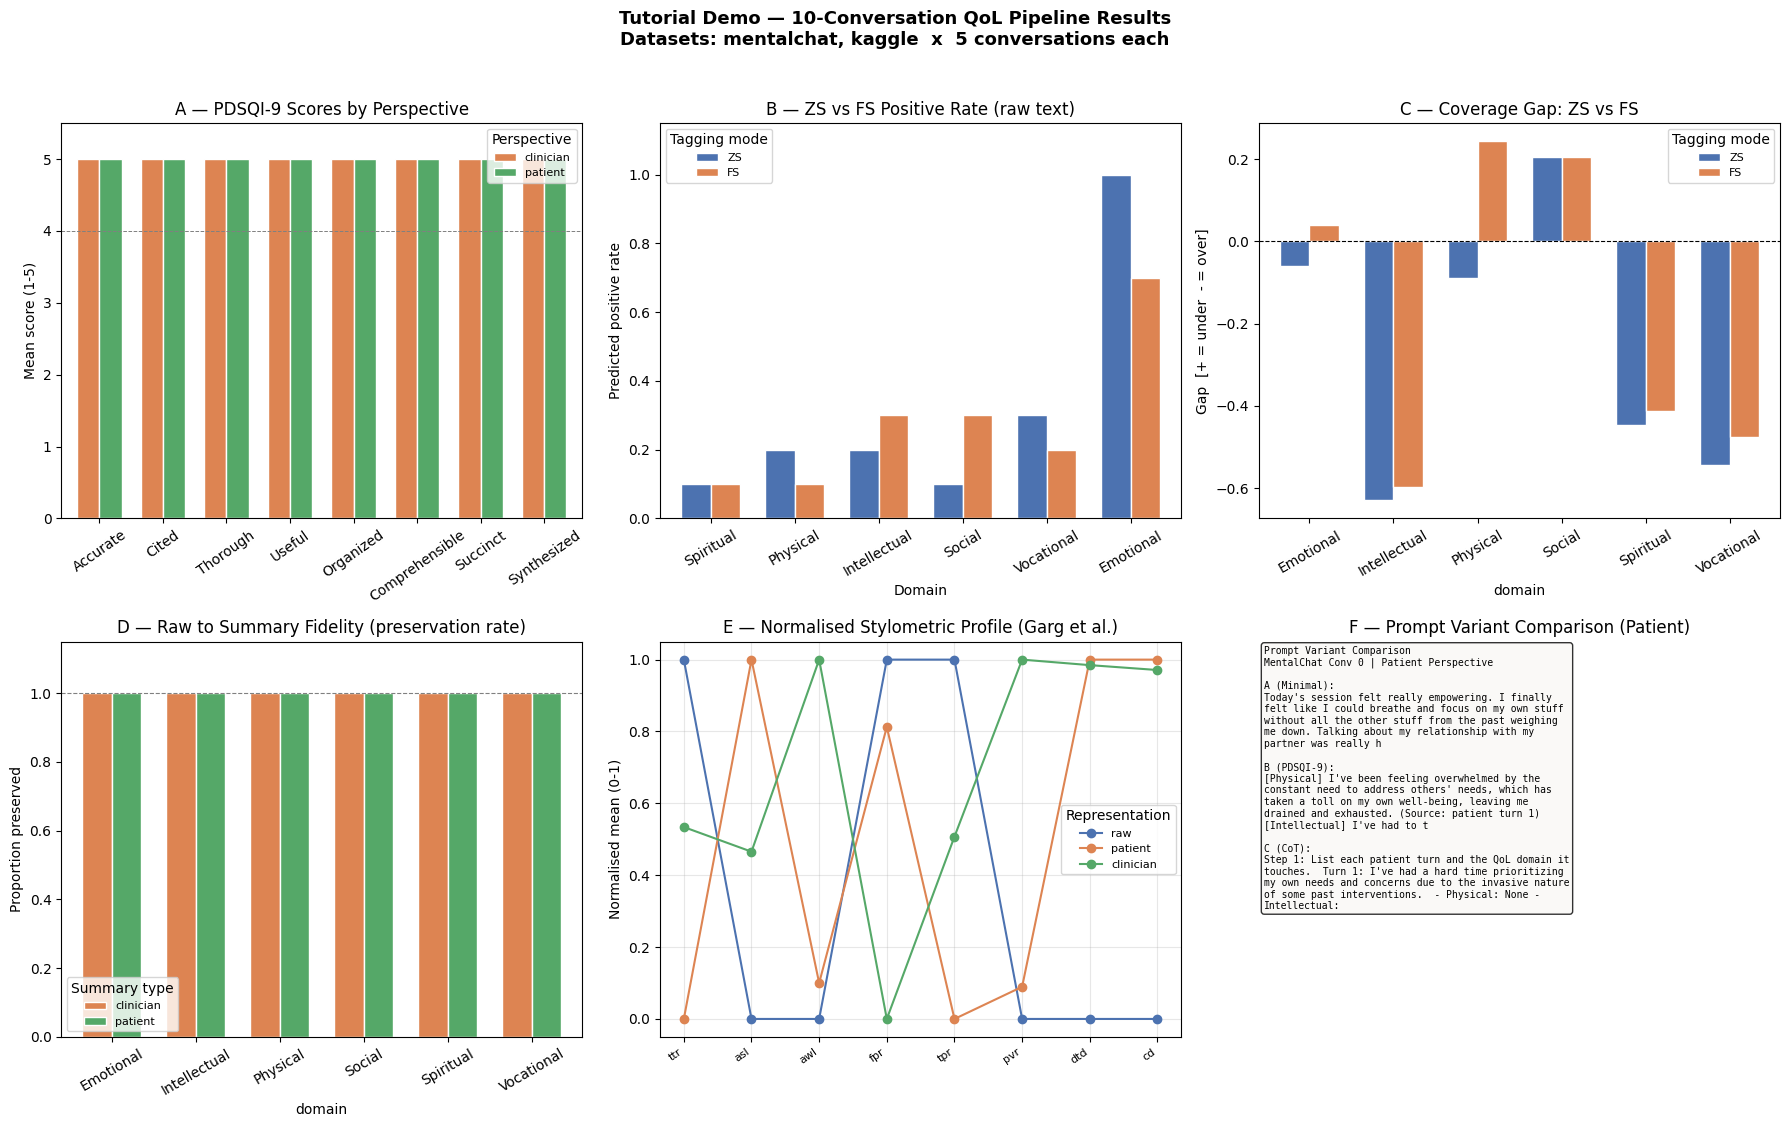

Dashboard saved: /content/drive/MyDrive/Colab Notebooks/Datasets/tutorial_demo_v3_2/tutorial_dashboard.png


In [ ]:
# T-5  Dashboard — 2x3 panel figure
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"Tutorial Demo — {len(all_demo_df)}-Conversation QoL Pipeline Results\n"
    f"Datasets: {', '.join(DATASET_SHEETS.keys())}  x  {N_DEMO} conversations each",
    fontsize=13, fontweight="bold", y=1.02)
PAL  = {"raw": "#4C72B0", "patient": "#DD8452", "clinician": "#55A868"}
REPS = ["raw", "patient", "clinician"]

# Panel A — PDSQI-9 mean scores by perspective
ax = axes[0, 0]
mean_scores = pdsqi_df.groupby("perspective")[LIKERT_COLS].mean()
mean_scores.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white",
                   color=["#DD8452","#55A868"])
ax.set_ylim(0, 5.5)
ax.set_title("A — PDSQI-9 Scores by Perspective")
ax.set_ylabel("Mean score (1-5)")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Perspective", fontsize=8)
ax.axhline(4.0, color="grey", linestyle="--", linewidth=0.7)

# Panel B — Zero-shot vs Few-shot domain prevalence (raw representation only)
ax = axes[0, 1]
prev_zs = tag_df_zs.groupby("representation")[[f"{k}_pred" for k in LABEL_COLS]].mean().reindex(REPS)
prev_fs = tag_df_fs.groupby("representation")[[f"{k}_pred" for k in LABEL_COLS]].mean().reindex(REPS)
# Show ZS and FS side-by-side for the "raw" representation
zs_raw = prev_zs.loc["raw"].rename("ZS")
fs_raw = prev_fs.loc["raw"].rename("FS")
pd.DataFrame([zs_raw, fs_raw]).rename(columns=lambda c: c.replace("_pred","")).T.plot(
    kind="bar", ax=ax, width=0.7, edgecolor="white", color=["#4C72B0","#DD8452"])
ax.set_ylim(0, 1.15)
ax.set_title("B — ZS vs FS Positive Rate (raw text)")
ax.set_ylabel("Predicted positive rate")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Tagging mode", fontsize=8)
ax.set_xlabel("Domain")

# Panel C — Coverage gap: ZS vs FS comparison (raw representation)
ax = axes[0, 2]
zs_gap = gap_df.groupby("domain")["coverage_gap"].mean()
fs_gap = gap_df_fs.groupby("domain")["coverage_gap"].mean()
gap_compare = pd.DataFrame({"ZS": zs_gap, "FS": fs_gap})
gap_compare.plot(kind="bar", ax=ax, width=0.7, edgecolor="white",
                 color=["#4C72B0","#DD8452"])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("C — Coverage Gap: ZS vs FS")
ax.set_ylabel("Gap  [+ = under  - = over]")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Tagging mode", fontsize=8)

# Panel D — Raw-to-summary fidelity
ax = axes[1, 0]
f_piv = (fid_df.groupby(["summary_rep","domain"])["raw_to_summary_preservation"]
         .mean().round(3).unstack("domain"))
f_piv.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white",
             color=["#DD8452","#55A868"])
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("D — Raw to Summary Fidelity (preservation rate)")
ax.set_ylabel("Proportion preserved")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Summary type", fontsize=8)

# Panel E — Normalised stylometric profile (Garg et al. 8 metrics)
ax = axes[1, 1]
mf   = stylo_df.groupby("representation")[FEAT_COLS].mean().reindex(REPS)
norm = (mf - mf.min()) / (mf.max() - mf.min() + 1e-9)
x2   = range(len(FEAT_COLS))
for rep in REPS:
    ax.plot(x2, norm.loc[rep], marker="o", label=rep, color=PAL[rep])
ax.set_xticks(list(x2))
ax.set_xticklabels(FEAT_COLS, rotation=35, ha="right", fontsize=8)
ax.set_title("E — Normalised Stylometric Profile (Garg et al.)")
ax.set_ylabel("Normalised mean (0-1)")
ax.legend(title="Representation", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel F — Prompt variant comparison (MultiWD conv 0, patient perspective)
ax = axes[1, 2]
ax.axis("off")
ref = summary_df[summary_df["dataset"]=="mentalchat"].iloc[0]["patient_summary"]
comp_text = (
    "Prompt Variant Comparison\nMentalChat Conv 0 | Patient Perspective\n\n"
    + "A (Minimal):\n" + textwrap.fill(pat_A[:220], 52)
    + "\n\nB (PDSQI-9):\n" + textwrap.fill(ref[:220], 52)
    + "\n\nC (CoT):\n" + textwrap.fill(pat_C[:220], 52)
)
ax.text(0.01, 0.99, comp_text, transform=ax.transAxes, fontsize=7.0,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#f9f8f5", alpha=0.8))
ax.set_title("F — Prompt Variant Comparison (Patient)")

plt.tight_layout()
dashboard_path = f"{OUT_DIR}/tutorial_dashboard.png"
plt.savefig(dashboard_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Dashboard saved: {dashboard_path}")


## Step T-6: Save Results + Closing Discussion

**What this step does:** Writes all computed DataFrames to a single Excel workbook,
one sheet per metric, mirroring the `Val_Outputs_Annotated_v2_Step6GoldEvalReport.xlsx` structure.

| Sheet | Contents | Rows |
|-------|----------|------|
| Summaries | raw_text, patient_summary, clinician_summary | 15 |
| QoLTagging_ZS | Zero-shot binary predictions per (conv_id, representation) | 30 |
| QoLTagging_FS | Few-shot binary predictions per (conv_id, representation) | 30 |
| PDSQI9Scores | 8 Likert scores + Non_Stigmatizing per summary | 20 |
| CoverageGap_ZS | Zero-shot coverage gap per (dataset, rep, domain) | 36 |
| CoverageGap_FS | Few-shot coverage gap per (dataset, rep, domain) | 36 |
| FidelityMatrix | raw_to_summary_preservation per (conv, domain, rep) — based on ZS | variable |
| Stylometrics | 8 Garg et al. features per (conv, representation) | 30 |


In [ ]:
# T-6  Save to Excel — mirrors Step6GoldEvalReport.xlsx sheet structure
out_path = f"{OUT_DIR}/tutorial_demo_10conv_results.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    summary_df[["dataset","conv_id","raw_text","patient_summary","clinician_summary"]].to_excel(
        writer, sheet_name="Summaries", index=False)
    tag_df_zs.to_excel(writer, sheet_name="QoLTagging_ZS", index=False)
    tag_df_fs.to_excel(writer, sheet_name="QoLTagging_FS", index=False)
    pdsqi_df.to_excel(writer, sheet_name="PDSQI9Scores", index=False)
    gap_df.to_excel(writer, sheet_name="CoverageGap_ZS", index=False)
    gap_df_fs.to_excel(writer, sheet_name="CoverageGap_FS", index=False)
    fid_df.to_excel(writer, sheet_name="FidelityMatrix", index=False)
    stylo_df.to_excel(writer, sheet_name="Stylometrics", index=False)

print(f"Results saved: {out_path}")
print("Sheets: Summaries | QoLTagging_ZS | QoLTagging_FS | PDSQI9Scores |")
print("        CoverageGap_ZS | CoverageGap_FS | FidelityMatrix | Stylometrics")


Results saved: /content/drive/MyDrive/Colab Notebooks/Datasets/tutorial_demo_v3_2/tutorial_demo_10conv_results.xlsx
Sheets: Summaries | QoLTagging_ZS | QoLTagging_FS | PDSQI9Scores |
        CoverageGap_ZS | CoverageGap_FS | FidelityMatrix | Stylometrics


---
## Closing Discussion — Right Model for the Right Task

**Central question:** Given your results, which model-prompt combination would you deploy
in a real clinical NLP pipeline?

| Dimension | Simpler model (Qwen 3B) | Larger model (LLaMA 8B / GPT) |
|-----------|------------------------|-------------------------------|
| Latency | Fast (1 s/conv) | Slow (3-10 s/conv) |
| Cost | Free / local | API cost or GPU cost |
| Privacy | Stays on-device | Data leaves institution |
| PDSQI-9 compliance | Moderate | Higher instruction-following |
| Fidelity | May miss rare domains | Better domain coverage |
| Reproducibility | Fully deterministic | Subject to API versioning |

### The simpler is better principle in clinical NLP

In production clinical systems, a 3 B parameter model fine-tuned on a small labelled set often
outperforms a 70 B model used zero-shot because the task is narrow and well-defined.

> *If your task has a fixed schema and your training data aligns with the test domain,
> prefer the smallest model that meets your quality bar.*

Summarisation changes this calculus — generating a fluent, PDSQI-9-compliant summary is harder
than binary classification; larger models tend to score better on **Cited** and **Organized**.

### Questions to take home
1. At what point does a model become good enough for PDSQI-9 compliance in a clinical audit?
2. How would you validate that a patient-perspective summary accurately represents the patient's
   intent rather than the clinician's interpretation?
3. If you could only run ONE representation through the QoL tagger, which would you choose —
   and does your answer change for different downstream use cases?


---
## Optional: ContextGem / LangExtract Structured Extraction Path

> **Note for tutorial presenters:** This section is commented out for the live demo.
> It demonstrates the `langextract` model option from T-0 using ContextGem typed schema
> extraction instead of freeform JSON prompting. Planned for future integration into the
> main research notebook.

**What ContextGem does differently:**
- Defines each QoL domain as a typed `Concept` with a `StringAspect` (yes/no value)
- The `LLMPipeline` validates types and retries automatically — no `parse_label_json` needed
- Eliminates parse errors at the cost of being coupled to the ContextGem API

**When to prefer it:** Production pipelines where parse errors are unacceptable and
schema reliability is critical.

**Tradeoff:** Less portable than plain `transformers` + `json.loads` calls.


In [ ]:
# # OPTIONAL: ContextGem Structured Extraction -- QoL Tagging
# # To activate:
# #   1. !pip install contextgem   (restart runtime after install)
# #   2. Set MODEL_CHOICE = 'langextract' in T-0
# #   3. Re-run T-0g to initialise cg_llm
# #   4. Run this cell
# #
# # What ContextGem does differently from freeform JSON prompting:
# #   - Each QoL domain is defined as a BooleanConcept with a natural-language yes/no question
# #   - DocumentLLM handles retries and type validation automatically
# #   - No parse_label_json() needed -- the output is schema-validated
# #   - Tradeoff: higher API cost per text (one extraction call covers all 6 domains)
# #
# # API note: LLMPipeline / Concept / StringAspect were removed in contextgem v0.10+.
# # Current API (v0.17+) uses: DocumentLLM, Document, BooleanConcept

# QOL_DOMAIN_DESCRIPTIONS = {
#     "Spiritual":    "Does this text mention spiritual well-being, faith, meaning, purpose, religion, or existential concerns?",
#     "Physical":     "Does this text mention physical health, bodily symptoms, pain, fatigue, medical conditions, or physical functioning?",
#     "Intellectual": "Does this text mention cognitive function, memory, concentration, learning, mental clarity, or intellectual activity?",
#     "Social":       "Does this text mention social relationships, interpersonal interactions, family, friends, community, or social support?",
#     "Vocational":   "Does this text mention work, employment, school, career, occupational functioning, or financial situation?",
#     "Emotional":    "Does this text mention emotional state, mood, feelings, mental health symptoms such as anxiety or depression, or psychological well-being?",
# }

# def contextgem_qol_tag(text, llm):
#     """
#     Tag a single text using ContextGem BooleanConcepts.

#     Parameters
#     ----------
#     text : str          The conversation text to tag.
#     llm  : DocumentLLM  A pre-configured DocumentLLM instance from T-0g.

#     Returns
#     -------
#     pred        : dict  {domain: 0/1} for all 6 LABEL_COLS
#     parse_error : int   1 if any concept returned no items, 0 otherwise
#     raw_out     : str   human-readable summary string
#     """
#     from contextgem import Document, BooleanConcept
#     default_pred = {d: 0 for d in LABEL_COLS}
#     text = str(text).strip()
#     if not text:
#         return default_pred, 1, "empty input"
#     try:
#         doc = Document(raw_text=text)
#         # add_concepts() is required -- direct .concepts assignment is not supported
#         doc.add_concepts([
#             BooleanConcept(
#                 name=domain,
#                 description=QOL_DOMAIN_DESCRIPTIONS[domain],
#                 singular_occurrence=True,
#             )
#             for domain in LABEL_COLS
#         ])
#         # raise_exception_on_extraction_error belongs on extract_all(), NOT on DocumentLLM()
#         doc = llm.extract_all(
#             doc,
#             overwrite_existing=True,
#             raise_exception_on_extraction_error=False,
#         )
#         pred, parse_error, raw_parts = {}, 0, []
#         for concept in doc.concepts:
#             items = concept.extracted_items
#             if items:
#                 val = int(bool(items[0].value))
#                 raw_parts.append(f"{concept.name}={val}")
#             else:
#                 val = 0
#                 parse_error = 1
#                 raw_parts.append(f"{concept.name}=MISSING")
#             pred[concept.name] = val
#         for d in LABEL_COLS:
#             if d not in pred:
#                 pred[d] = 0
#                 parse_error = 1
#         return pred, parse_error, "; ".join(raw_parts)
#     except Exception as e:
#         return default_pred, 1, f"Exception: {e}"


# # ---- Run ContextGem --------------------------------------------------------
# if LANGEXTRACT_AVAILABLE and cg_llm is not None:
#     import time

#     # -- Sanity check: single text -------------------------------------------
#     print("=== ContextGem sanity check: MultiWD conv 0 ===\n")
#     test_row  = all_demo_df[all_demo_df["dataset"] == "multiwd"].iloc[0]
#     test_text = test_row["text"]
#     print(f"Text preview: {str(test_text)[:200]}...\n")

#     cg_labels, cg_err, cg_raw = contextgem_qol_tag(test_text, cg_llm)
#     print(f"ContextGem labels : {cg_labels}")
#     print(f"Raw output        : {cg_raw}")
#     print(f"Parse error flag  : {cg_err}\n")

#     # -- Comparison with freeform JSON (if another backend is also loaded) ---
#     if gen is not None:
#         json_labels, _, _ = call_open_qol_classifier(test_text)
#         print(f"Freeform JSON labels : {json_labels}")
#         diffs = {k: (cg_labels.get(k, 0), json_labels.get(k, 0))
#                  for k in LABEL_COLS if cg_labels.get(k, 0) != json_labels.get(k, 0)}
#         print(f"Differences          : {diffs if diffs else 'none -- perfect agreement'}")
#     elif gpt_client is not None:
#         json_labels, _, _ = call_gpt_qol_classifier(test_text)
#         print(f"Freeform JSON labels : {json_labels}")
#         diffs = {k: (cg_labels.get(k, 0), json_labels.get(k, 0))
#                  for k in LABEL_COLS if cg_labels.get(k, 0) != json_labels.get(k, 0)}
#         print(f"Differences          : {diffs if diffs else 'none -- perfect agreement'}")
#     else:
#         print("(No second backend for comparison. Set MODEL_CHOICE to gpt or qwen and re-run T-0g.)")

#     # -- Full run: all 15 demo rows ------------------------------------------
#     print("\n=== Full demo run: ContextGem across all 15 conversations ===")
#     cg_rows = []
#     for _, row in all_demo_df.iterrows():
#         pred, err, raw = contextgem_qol_tag(row["text"], cg_llm)
#         r = {
#             "conv_id":        row["conv_id"],
#             "dataset":        row["dataset"],
#             "representation": "raw",
#             "parse_error":    err,
#             "raw_out":        raw,
#         }
#         r.update({f"{d}_pred": pred[d] for d in LABEL_COLS})
#         cg_rows.append(r)
#         time.sleep(0.3)    # gentle rate-limit to stay within API quotas

#     cg_df = pd.DataFrame(cg_rows)
#     display_cols = ["dataset", "conv_id"] + [f"{d}_pred" for d in LABEL_COLS]
#     print(cg_df[display_cols].to_string(index=False))

#     print("\n=== Aggregate positive rate per domain (ContextGem, raw text) ===")
#     print(cg_df[[f"{d}_pred" for d in LABEL_COLS]].mean().round(2).to_string())

#     print("\n=== Parse error rate ===")
#     print(f"{cg_df['parse_error'].sum()} / {len(cg_df)} rows had missing extractions")

# else:
#     print("ContextGem is not active.")
#     print("To run this section:")
#     print("  1. !pip install contextgem   (then restart the runtime)")
#     print("  2. Set MODEL_CHOICE = 'langextract' in T-0")
#     print("  3. Re-run T-0g, then re-run this cell")


ContextGem is not active.
To run this section:
  1. !pip install contextgem   (then restart the runtime)
  2. Set MODEL_CHOICE = 'langextract' in T-0
  3. Re-run T-0g, then re-run this cell
